In [13]:
from langchain_openrouter import ChatOpenRouter
import getpass
import os
from dotenv import load_dotenv
from IPython.display import display, Markdown

load_dotenv()

if not os.getenv("OPENROUTER_API_KEY"):
    os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API key: ")

if not os.getenv("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API key: ")


model = ChatOpenRouter(
    model="openai/gpt-3.5-turbo",
    max_tokens=400,
    # reasoning={'effort': 'minimal'}
)

### Intro

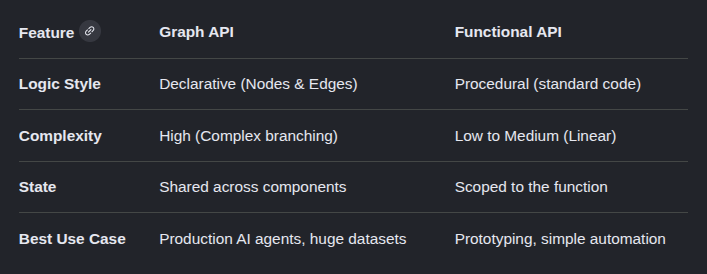

#### Using Graph API

In [14]:
# 1. Define tools and model
from langchain.tools import tool
from langchain.chat_models import init_chat_model

@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b

tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

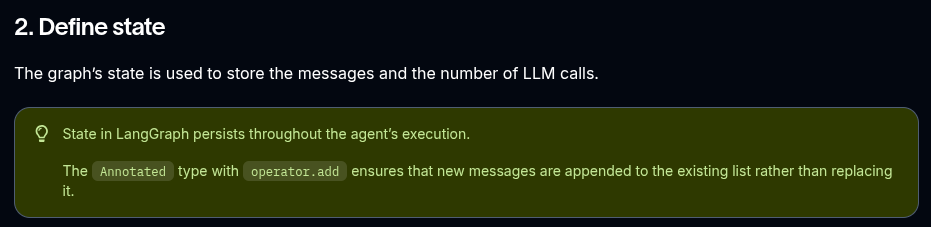

In [15]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

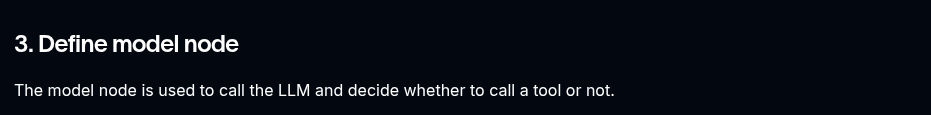

In [16]:
from langchain.messages import SystemMessage

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        'messages': [
            model_with_tools.invoke(
                [
                    SystemMessage(content='You are a helpful assistant tasked with performing arithmetic on a set of inputs.')
                ]
                + state['messages']
            )
        ],
        'llm_calls': state.get('llm_calls',0) + 1
    }

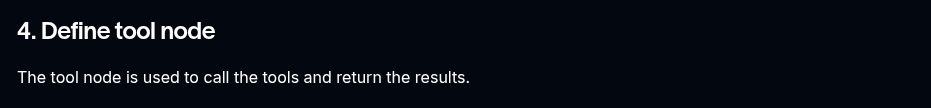

In [17]:
from langchain.messages import ToolMessage

def tool_node(state: dict):
    """Perform the tool call"""

    result = []
    for tool_call in state['messages'][-1].tool_calls:
        tool = tools_by_name[tool_call['name']]
        observation = tool.invoke(tool_call['args'])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call['id']))
    return {'messages': result}

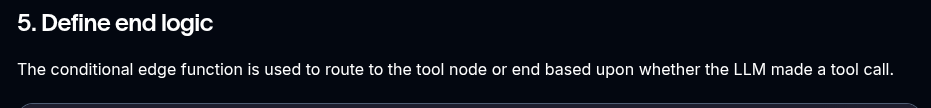

In [18]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

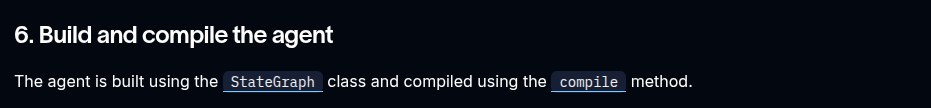

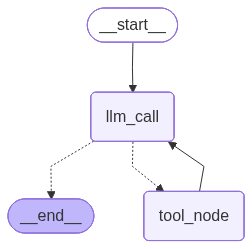

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_bBNHKDPbLq7CjJ3jwTxBPrT6)
 Call ID: call_bBNHKDPbLq7CjJ3jwTxBPrT6
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [19]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

#### Using Functional API

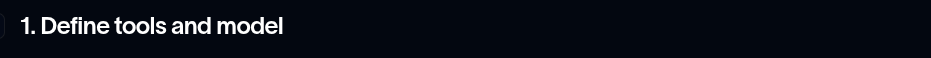

In [20]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

from langgraph.graph import add_messages
from langchain.messages import (
    SystemMessage,
    HumanMessage,
    ToolCall,
)
from langchain_core.messages import BaseMessage
from langgraph.func import entrypoint, task

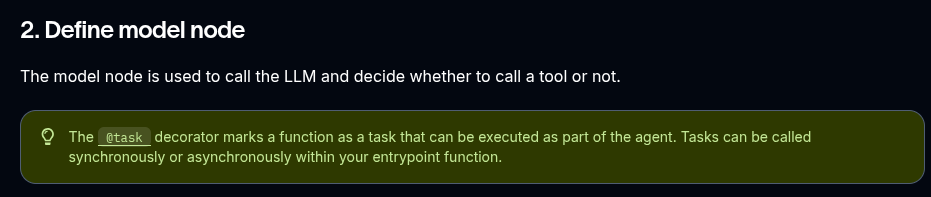

In [21]:
@task
def call_llm(messages: list[BaseMessage]):
    """LLM decides whether to call a tool or not"""
    return model_with_tools.invoke(
        [
            SystemMessage(
                content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
            )
        ]
        + messages
    )

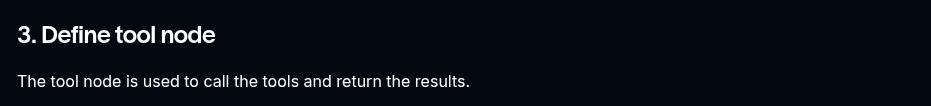

In [22]:
@task
def call_tool(tool_call: ToolCall):
    """Perform the tool call"""
    tool = tools_by_name[tool_call['name']]
    return tool.invoke(tool_call)

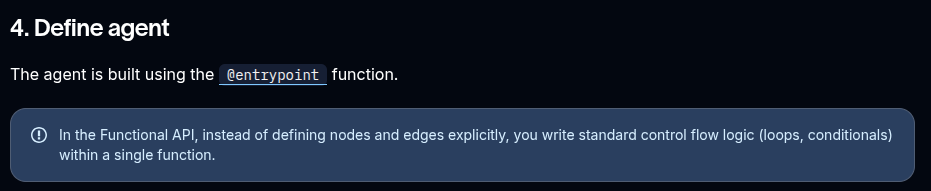

In [23]:
@entrypoint()
def agent(messages: list[BaseMessage]):
    model_response = call_llm(messages).result()

    while True:
        if not model_response.tool_calls:
            break

        tool_result_futures = [call_tool(tool_call) for tool_call in model_response.tool_calls]
        tool_results = [fut.result() for fut in tool_result_futures]
        messages = add_messages(messages, [model_response, *tool_results])
        model_response = call_llm(messages).result()

    messages = add_messages(messages, model_response)
    return messages

messages = [HumanMessage(content='Add 3 and 4.')]
for chunk in agent.stream(messages, stream_mode='updates'):
    print(chunk)
    print('\n')

{'call_llm': AIMessage(content='', additional_kwargs={}, response_metadata={'model_name': 'openai/gpt-3.5-turbo', 'id': 'gen-1779351709-3ZzLKcygotS9tVgSGnnG', 'created': 1779351709, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019e49a0-6460-7540-bc72-875fb826f4c3-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_rbFYIqLdSjOioWePrk4fH2hZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 171, 'output_tokens': 17, 'total_tokens': 188, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 0}})}


{'call_tool': ToolMessage(content='7', name='add', tool_call_id='call_rbFYIqLdSjOioWePrk4fH2hZ')}


{'call_llm': AIMessage(content='The sum of 3 and 4 is 7.', additional_kwargs={}, response_metadata={'model_name': 'openai/gpt-3.5-turbo', 'id': 'gen-1779351710-GBOfuCLF1GySYaCcRenn', 'created': 1779351710, 'object': 'chat.compl